# Set up

In [43]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.image import imread
import seaborn as sns
import pandas as pd
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [44]:
A_simple = np.array([[1,2,3],
            [4,5,6],
            [7,8,9],
            [10,11,12]])

In [45]:
# Display the matrix
def plot_matrix(matrix, title="Matrix", annotate=True):
    """Plot a matrix as a heatmap with annotations."""
    if isinstance(matrix, np.ndarray):
        matrix_np = matrix
    else:
        matrix_np = matrix.numpy()
        
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(matrix_np, annot=annotate, fmt=".2f", 
                    linewidths=1, cbar=True, cmap="Blues")
    plt.title(title)
    
    # Add row and column indices
    ax.set_xticks(np.arange(matrix_np.shape[1]) + 0.5)
    ax.set_yticks(np.arange(matrix_np.shape[0]) + 0.5)
    ax.set_xticklabels([f"Col {i+1}" for i in range(matrix_np.shape[1])])
    ax.set_yticklabels([f"Row {i+1}" for i in range(matrix_np.shape[0])])
    
    plt.tight_layout()
    plt.show()

# SVD function

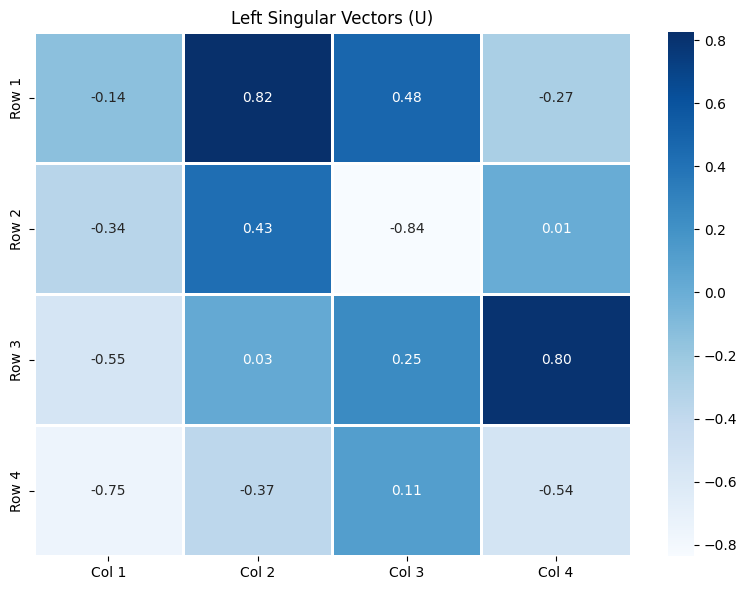

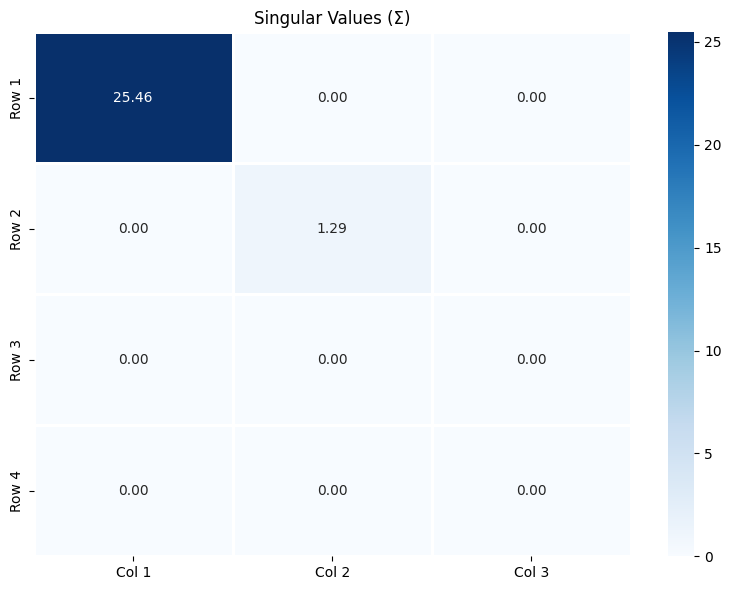

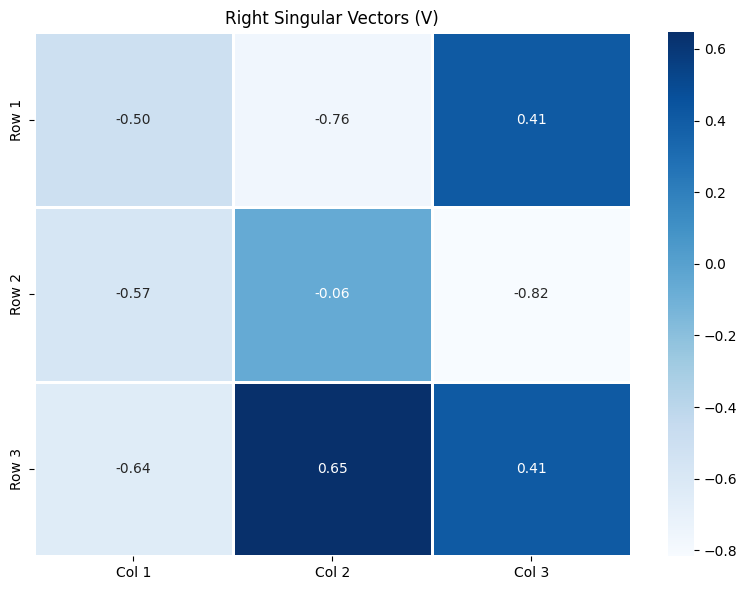

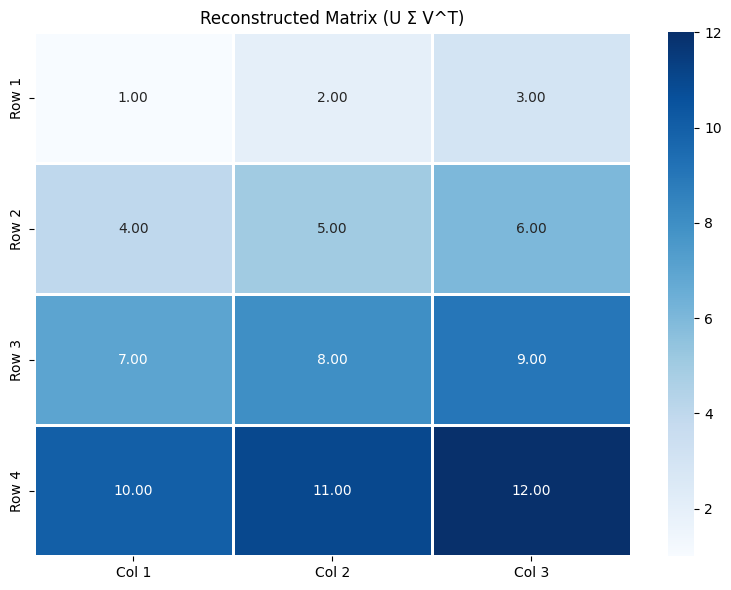

Reconstruction error: 3.43e-14


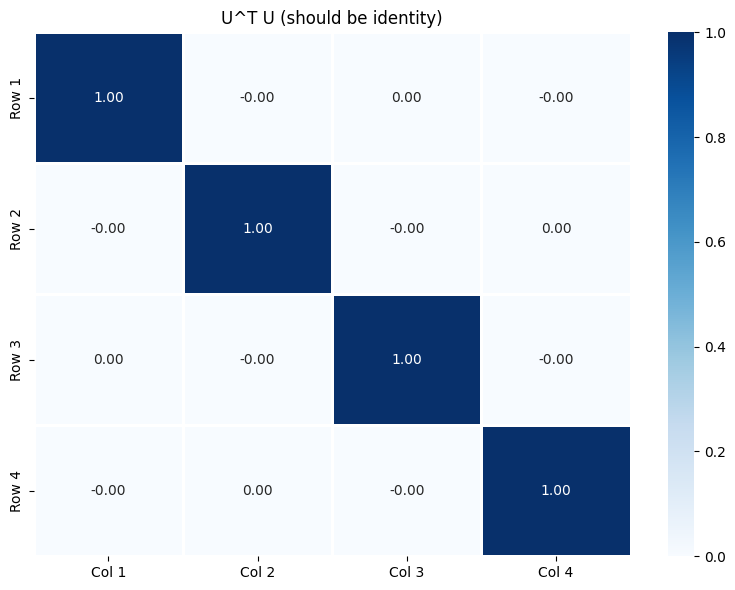

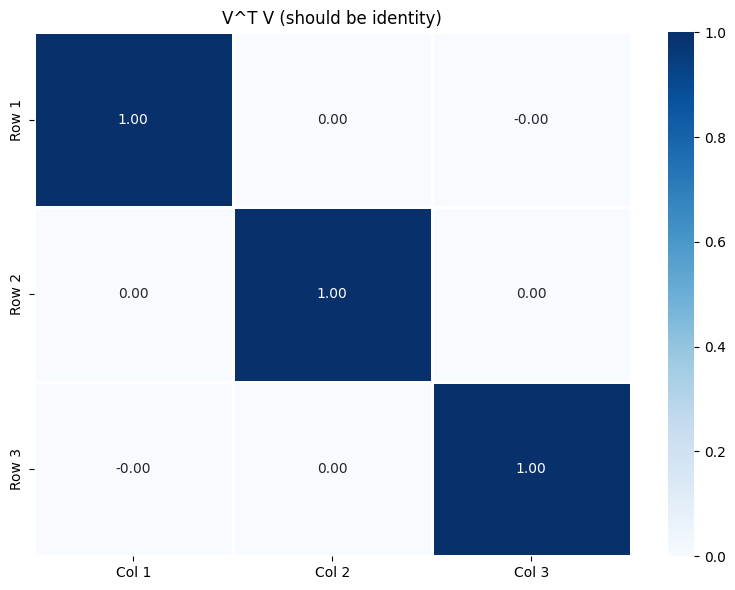

In [46]:
def compute_svd_via_eigen(A):
    """
    Compute SVD using eigendecomposition of A^T A and A A^T.
    
    Args:
        A: Input matrix as a NumPy array
        
    Returns:
        U: Left singular vectors
        S: Singular values (diagonal matrix)
        V: Right singular vectors
    """
    
    m, n = A.shape
    
    # Compute A^T A and A A^T
    ATA = A.T @ A  # n x n
    AAT = A @ A.T  # m x m
    
    # Get eigenvalues and eigenvectors of A^T A
    eigvals_ATA, eigvecs_ATA = np.linalg.eigh(ATA)
    
    # Get eigenvalues and eigenvectors of A A^T
    eigvals_AAT, eigvecs_AAT = np.linalg.eigh(AAT)
    
    # Sort eigenvalues and eigenvectors in descending order
    sorted_indices_ATA = np.argsort(eigvals_ATA)[::-1]
    eigvals_ATA = eigvals_ATA[sorted_indices_ATA]
    eigvecs_ATA = eigvecs_ATA[:, sorted_indices_ATA]
    
    sorted_indices_AAT = np.argsort(eigvals_AAT)[::-1]
    eigvals_AAT = eigvals_AAT[sorted_indices_AAT]
    eigvecs_AAT = eigvecs_AAT[:, sorted_indices_AAT]
    
    # Compute singular values (square roots of eigenvalues of A^T A)
    S = np.sqrt(np.maximum(eigvals_ATA, 0))
    
    # Set V as eigenvectors of A^T A
    V = eigvecs_ATA
    
    # Set U as eigenvectors of A A^T
    U = eigvecs_AAT
    
    # Handle non-square matrices
    min_dim = min(m, n)
    
    # Compute U columns using A V_i = sigma_i * U_i
    for i in range(min_dim):
        if S[i] > 1e-10:
            U[:, i] = (A @ V[:, i]) / S[i]
    
    # Create full Sigma matrix
    S_full = np.zeros((m, n))
    for i in range(min(m, n)):
        S_full[i, i] = S[i]
    
    return U, S_full, V

# Test SVD on the example matrix
U_simple, S_simple, V_simple = compute_svd_via_eigen(A_simple)
# Display the matrices
plot_matrix(U_simple, "Left Singular Vectors (U)")
plot_matrix(S_simple, "Singular Values (Σ)")
plot_matrix(V_simple, "Right Singular Vectors (V)")

# Verify that A = U Σ V^T
reconstructed_A = U_simple @ S_simple @ V_simple.T
plot_matrix(reconstructed_A, "Reconstructed Matrix (U Σ V^T)")

# Calculate reconstruction error
reconstruction_error = np.linalg.norm(A_simple - reconstructed_A).item()
print(f"Reconstruction error: {reconstruction_error:.2e}")

# Verify that U and V are orthogonal
U_orthogonality = U_simple.T @ U_simple
V_orthogonality = V_simple.T @ V_simple

plot_matrix(U_orthogonality, "U^T U (should be identity)")
plot_matrix(V_orthogonality, "V^T V (should be identity)")


# Image compression

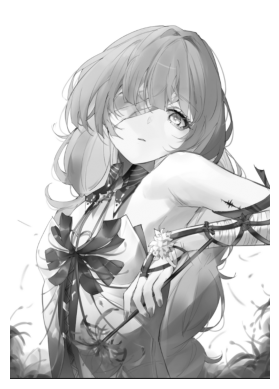

In [47]:
#improting image using imread(matplotlib.image)
A = imread("test.png")
#convert RGB into gray scale
X = np.mean(A,-1)
#plot the image
img = plt.imshow(X)
#set the color to gray
img.set_cmap("gray")
#turn off axis
plt.axis("off")
plt.show()

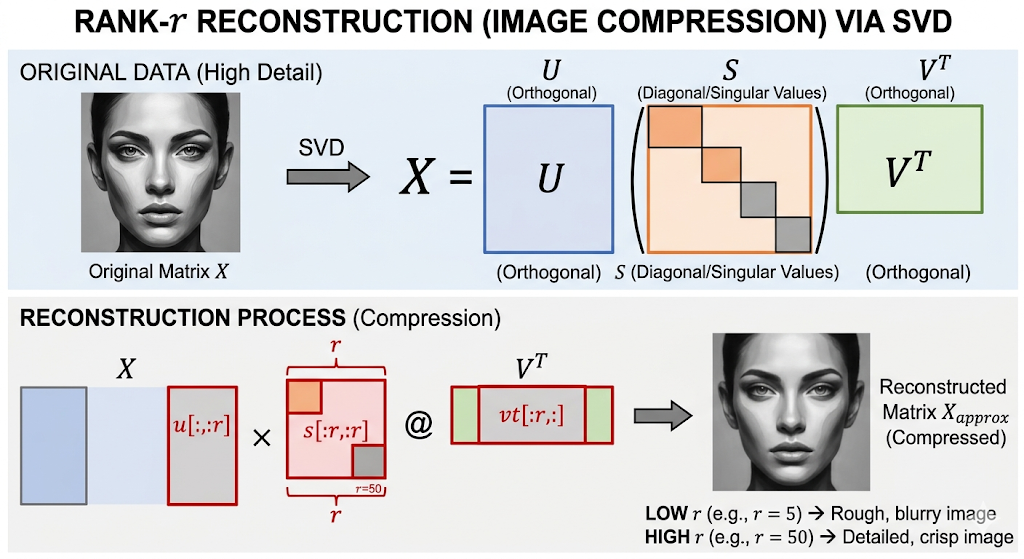

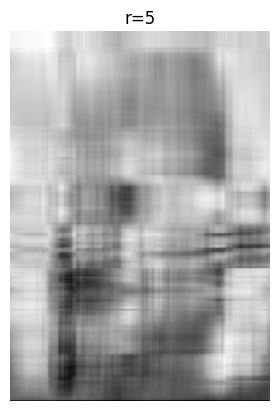

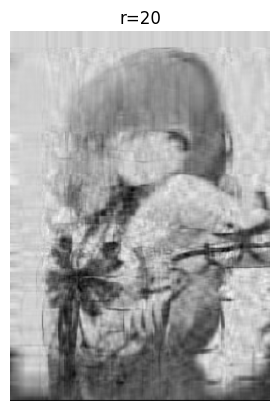

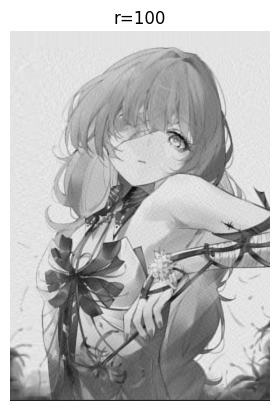

In [48]:
#use the built in svd cuz i don't trust my own function 
u,s,vt = np.linalg.svd(X,full_matrices=False)
#setting full_matrices to false mean we're doing the economy svd meaning we only want the first
#m columns of u that coresponding to the non zero singuler value this just mean if u don't have value u go to hell
#Next we need the diagonal value of the sigma matrix 
s = np.diag(s)
j = 0
for r in (5,20,100):
    Xapprox = u[:,:r]@s[:r,:r]@vt[:r,:]
    #we keep the first r columns of u the first r columns and row of sigma and the first row of vt
    #the reason our img don't get cut in two from this row/column cut because u and v itself is not the data
    #it's the direction of data and np.linalg.svd auto sord the biggest stuff on the first row some how so
    #by keeping the first r element we keep all the important stuff
    plt.figure(j+1)
    #set the figure size and display image
    img = plt.imshow(Xapprox)
    img.set_cmap("gray")
    plt.axis("off")
    plt.title("r="+str(r))
    plt.show()


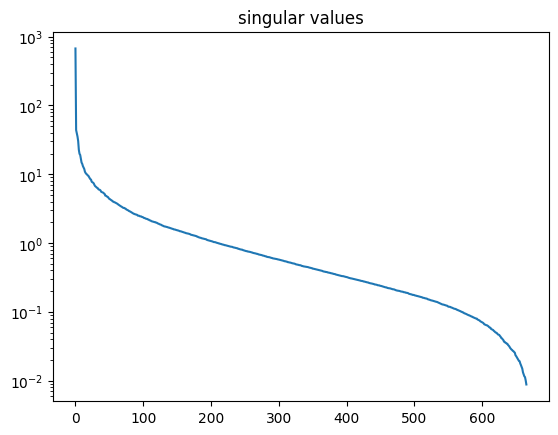

In [49]:
#this is all the value of the sigma
#this tell us how strong each rank is
#we can tell that this is sorted cuz the value isn't all over the place
#we log this cuz the first sigular value is massive compare to the rest 
#we want a some what good range and log can do that
plt.figure(1)
plt.semilogy(np.diag(s))
plt.title('singular values')
plt.show()

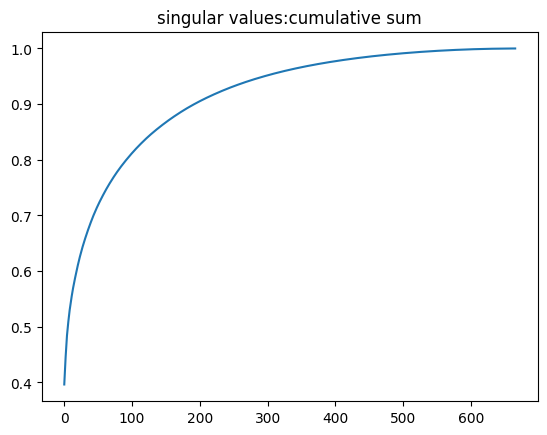

In [50]:
#we do cumsum to see how much r we need to keep most of the data
#by the picture r=100 keep 80%+ of the data already and going further is a waste
plt.figure(2)
plt.plot(np.cumsum(np.diag(s)/np.sum(np.diag(s))))
plt.title('singular values:cumulative sum')
plt.show()

# 2. Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that identifies the directions (principal components) in which the data varies the most. It transforms the original data into a new coordinate system where the axes correspond to the directions of maximum variance.

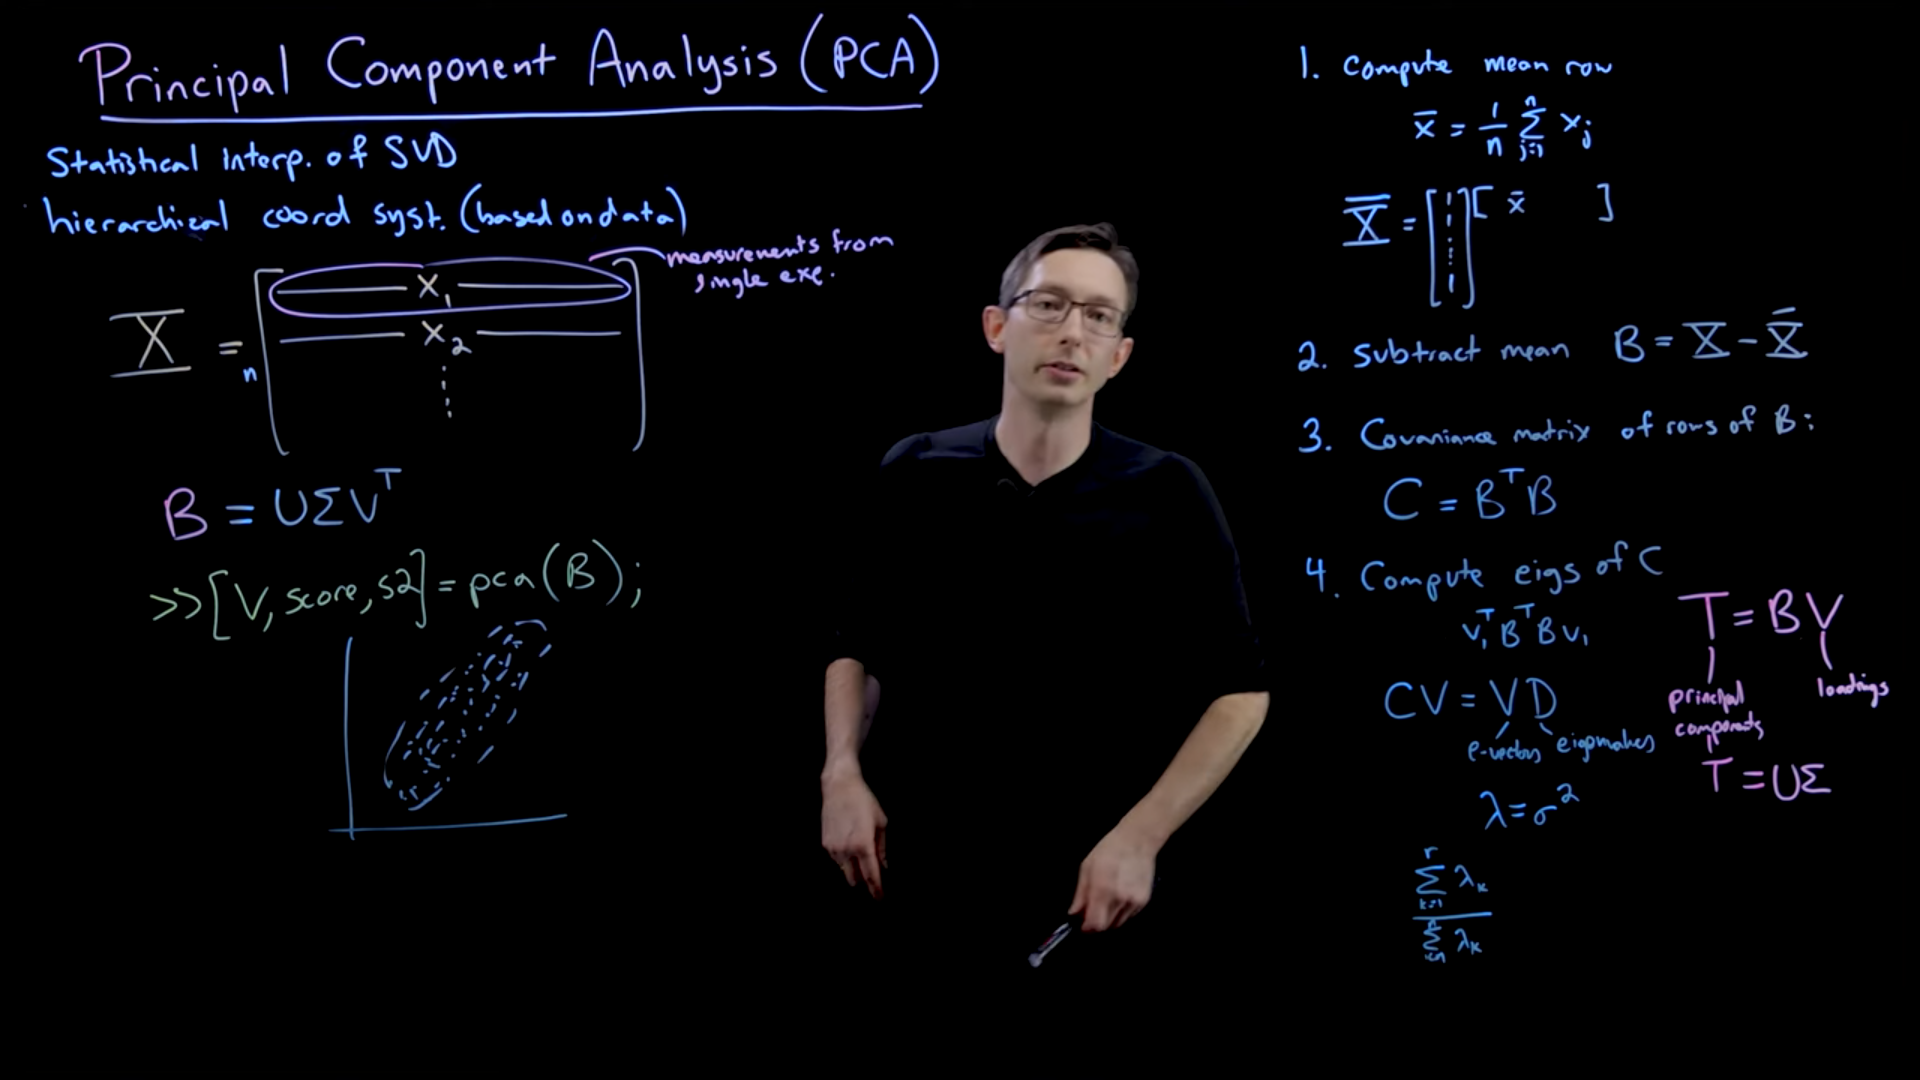

* pca wrok by finding the eigenvectors and eigenvalues of the covariance matrix of the data. The eigenvectors represent the directions of maximum variance, while the eigenvalues indicate the amount of variance captured by each principal component. By selecting the top k eigenvectors (based on their corresponding eigenvalues), we can reduce the dimensionality of the data while retaining most of its variability.
* we get the covariance matrix by centering the data (subtracting the mean) and then calculating the covariance between each pair of features. The eigenvectors and eigenvalues are then computed from this covariance matrix, allowing us to identify the principal components and their corresponding variances.
* noices how that's very similar to SVD?
* the sigma values are the eigenvalues of the covariance matrix(the variance between the features), so if we want to capture 90% of the variance, we can look at the cumulative sum of the eigenvalues and select the top k eigenvectors that correspond to the largest eigenvalues until we reach 90% of the total variance. This way, we can reduce the dimensionality of the data while retaining most of its variability.

In [51]:
def pca_with_svd(X, n_components=2):
    # Center the data
    X_centered = X - np.mean(X, axis=0)
    
    # Compute SVD
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    
    # Principal components are right singular vectors (rows of Vt)
    components = Vt[:n_components]
    
    # Project data onto principal components
    X_transformed = X_centered @ components.T
    
    # Variance explained is proportional to squared singular values
    total_variance = np.sum(S**2)
    explained_variance = (S**2)[:n_components] / total_variance
    
    return X_transformed, components, explained_variance

In [52]:
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [53]:
dataset.data.shape

(1797, 64)

In [54]:
# get the first row
dataset.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

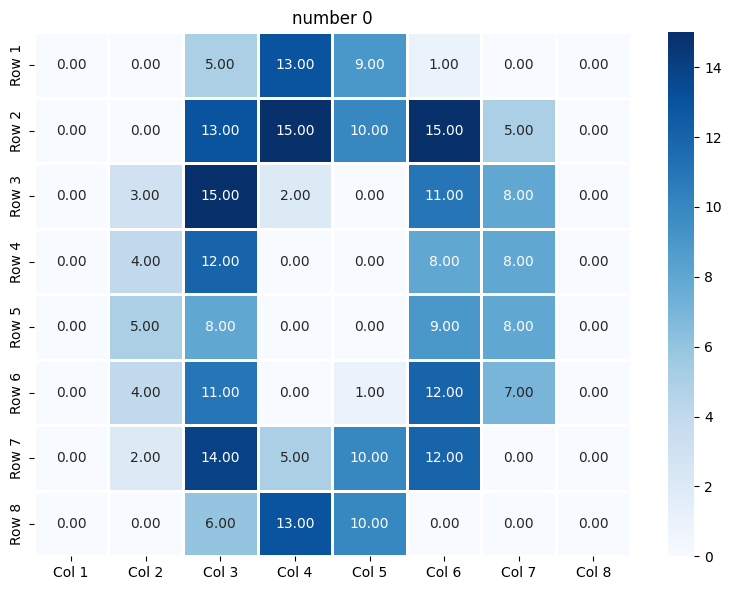

In [55]:
plot_matrix(dataset.data[0].reshape(8, 8), 'number 0')

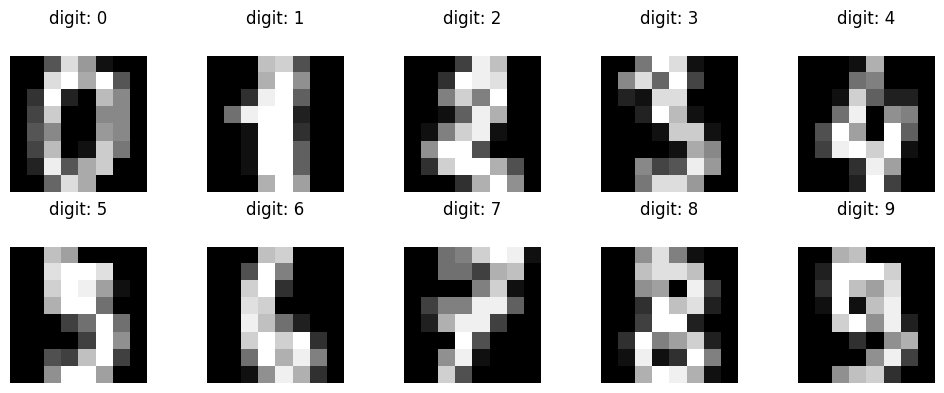

In [56]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit in range(10):
    # find first occurrence of each digit
    idx = np.where(dataset.target == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.matshow(dataset.data[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"digit: {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [57]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
X = df
y = dataset.target

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [59]:
model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9666666666666667

In [60]:
X_transformed, components, explained_variance = pca_with_svd(X,2)

In [61]:
components.shape

(2, 64)

In [62]:
print(f"2 components can explain around {round(explained_variance.sum(),4)*100} % of the variance.")

2 components can explain around 28.51 % of the variance.


In [63]:
X_transformed.shape

(1797, 2)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=30)

In [65]:
model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.6027777777777777

In [74]:
# if we want to explain 95% of the original data we do this
# Your loop
for i in range(1, 65):
    X_transformed, components, explained_variance = pca_with_svd(X, i)
    print(f"{i} components combine can explain around {round(explained_variance.sum(),2)*100} %")
    X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=30)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    print(f"The model accuracy:{round(model.score(X_test, y_test),2)*100} %")
    if explained_variance.sum() >= 0.95:
        break

1 components combine can explain around 15.0 %
The model accuracy:34.0 %
2 components combine can explain around 28.999999999999996 %
The model accuracy:60.0 %
3 components combine can explain around 40.0 %
The model accuracy:67.0 %
4 components combine can explain around 49.0 %
The model accuracy:81.0 %
5 components combine can explain around 54.0 %
The model accuracy:85.0 %
6 components combine can explain around 59.0 %
The model accuracy:86.0 %
7 components combine can explain around 64.0 %
The model accuracy:88.0 %
8 components combine can explain around 67.0 %
The model accuracy:91.0 %
9 components combine can explain around 71.0 %
The model accuracy:93.0 %
10 components combine can explain around 74.0 %
The model accuracy:94.0 %
11 components combine can explain around 76.0 %
The model accuracy:93.0 %
12 components combine can explain around 78.0 %
The model accuracy:95.0 %
13 components combine can explain around 80.0 %
The model accuracy:94.0 %
14 components combine can explain

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=30)

In [68]:
model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9722222222222222

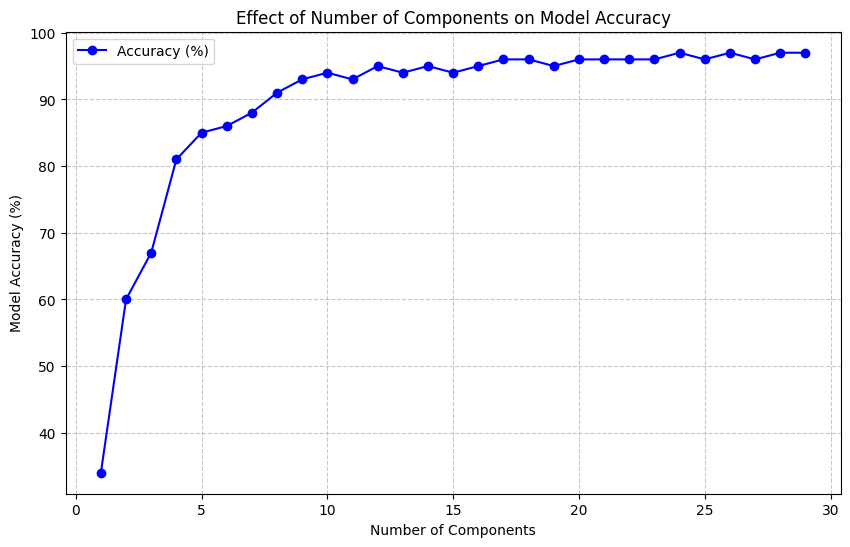

In [75]:
# Assuming you have these lists from your loop
components = list(range(1, 30)) # or however many you ran
accuracy = [34.0, 60.0, 67.0, 81.0, 85.0, 86.0, 88.0, 91.0, 93.0, 94.0, 93.0, 95.0, 94.0, 95.0, 94.0, 95.0, 96.0, 96.0, 95.0, 96.0, 96.0, 96.0, 96.0, 97.0, 96.0, 97.0, 96.0, 97.0, 97.0]

plt.figure(figsize=(10, 6))

# Plot the Accuracy
plt.plot(components, accuracy, marker='o', linestyle='-', color='b', label='Accuracy (%)')

# Add labels and title
plt.title('Effect of Number of Components on Model Accuracy')
plt.xlabel('Number of Components')
plt.ylabel('Model Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Show the plot
plt.show()